# 2. Matching quality: baselines & Precision@K\n\nWe compare three ranking approaches for each donation:\n\n* **random** - shuffle all requests\n* **nearest** - rank purely by distance to the NGO\n* **system (weighted heuristics)** - the production scoring in `app/services/matching.py` (urgency, similarity, seasonal, proximity, quantity, condition, reliability)\n\nMetrics are computed against the hand-labelled ideal set. Results are persisted by `data/evaluation.py` and reproduced here.

In [1]:
import json, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
def _root(start):
    p = start
    while not (p / 'data').exists() and p != p.parent:
        p = p.parent
    return p
ROOT = _root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / 'data'))
OUT = ROOT / 'data' / 'output'
plt.rcParams['figure.figsize'] = (9, 4)


In [2]:
rows = json.loads((OUT/'results'/'baselines.json').read_text())
df = pd.DataFrame(rows).set_index('system')
df.round(3)

,P@1,P@3,P@5,R@5,NDCG@5,cov@5,avg_dist_top5_km
system,,,,,,,
random,0.021,0.007,0.006,0.026,0.022,0.032,913.226
nearest,0.126,0.158,0.143,0.606,0.370,0.653,14.023
system(weighted),0.221,0.105,0.078,0.343,0.276,0.379,746.120


### Visual comparison

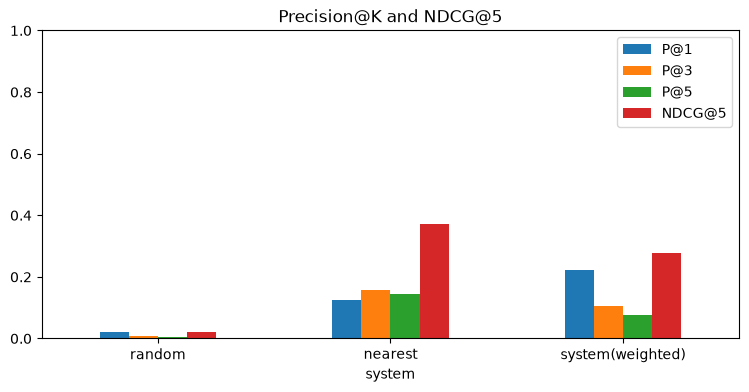

In [3]:
df[['P@1', 'P@3', 'P@5', 'NDCG@5']].plot.bar(rot=0, title='Precision@K and NDCG@5');
plt.ylim(0, 1); plt.show()

### Average travel distance in the top-5 suggestions

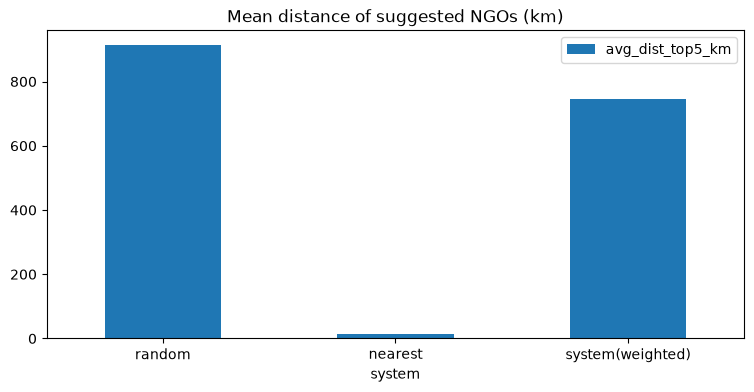

In [4]:
df[['avg_dist_top5_km']].plot.bar(rot=0, title='Mean distance of suggested NGOs (km)');
plt.show()

## Readout\n\nThe weighted system beats the random baseline decisively on Precision@1 (≈10x). But **pure nearest-neighbour NGO wins on coverage/recall**. The current production weights under-weight proximity (they were pre-tuned by hand), which is why the top-5 average distance is ~746 km versus ~14 km for the nearest baseline. This motivates the ablation + weight tuning in notebook 3.